In [1]:
import pandas as pd
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

In [2]:
from src.data_loader import load_dataset_consolide
df = load_dataset_consolide()

2026-04-21 21:37:07,242 - INFO - Dataset consolidé : 715,349 lignes | 26 colonnes
2026-04-21 21:37:07,250 - INFO - Période : 2021-01-01 00:00:00 → 2025-12-31 22:00:00


On cherche à répondre à la question suiva,te: "Dans quelle mesure peut-on prédire, pour chaque station de mesure, le dépassement du seuil réglementaire de PM2.5 (25 µg/m³) dans les 24 prochaines heures à partir d’observations de pollution atmosphérique, de variables météorologiques, de données de trafic routier et des sorties d’un modèle physique atmosphérique ?"

Le modèle est estimé sur l’ensemble des stations afin de mutualiser l’information disponible. Les performances sont ensuite évaluées à la fois globalement et de manière désagrégée par station. Cette approche permet d’identifier d’éventuelles disparités spatiales dans la qualité des prédictions et d’évaluer la robustesse du modèle à l’échelle locale.

On doit d'abord enlever les valeurs manquantes pour éviter que le modèle plante

In [3]:
df = df.dropna()

On trie ensuite les colonnes en fonction de la date

In [4]:
df = df.sort_values("datetime_debut")
df.columns = df.columns.str.strip()

Certaines variables inutiles doivent être supprimer avant l'entrainement du modèle, sinon le modèle entrainera du bruit

In [5]:
df = df.drop(columns=["type_station", "lon", "lat", "distance_km", "datetime_debut"])

On définit ensuite le vecteur des features à utiliser dans notre modèle

In [6]:
features = [
    "pm25_lag1h",
    "pm25_lag6h",
    "pm25_lag24h",
    "pm25_roll24h",
    "pm25_roll72h",
    "vent_vitesse_ms",
    "vent_direction_deg",
    "temperature_c",
    "humidite_pct",
    "pluie_mm",
    "nb_installations_5km",
    "heure",
    "jour_semaine",
    "mois",
    "is_weekend"
]

target = "depasse_seuil_24h"

In [7]:
from src.models import prepare_features, temporal_split, evaluate_model, train_cart, train_random_forest, train_logistic_regression

X,y = prepare_features(df, features, target)
X_train, X_test, y_train, y_test = temporal_split(X, y, train_size=0.8)

On en entraine alors successivement les modèles CART, forêt aléatoire et régression logitique

In [8]:
model_cart = train_cart(X_train, y_train, max_depth=3, min_samples_leaf=50, random_state=42)
model_rf = train_random_forest(X_train, y_train, n_estimators=100, max_depth=5, min_samples_leaf=50, random_state=42)
model_log = train_logistic_regression(X_train, y_train, X_test)

On peut par exemple visualiser l'arbre CART

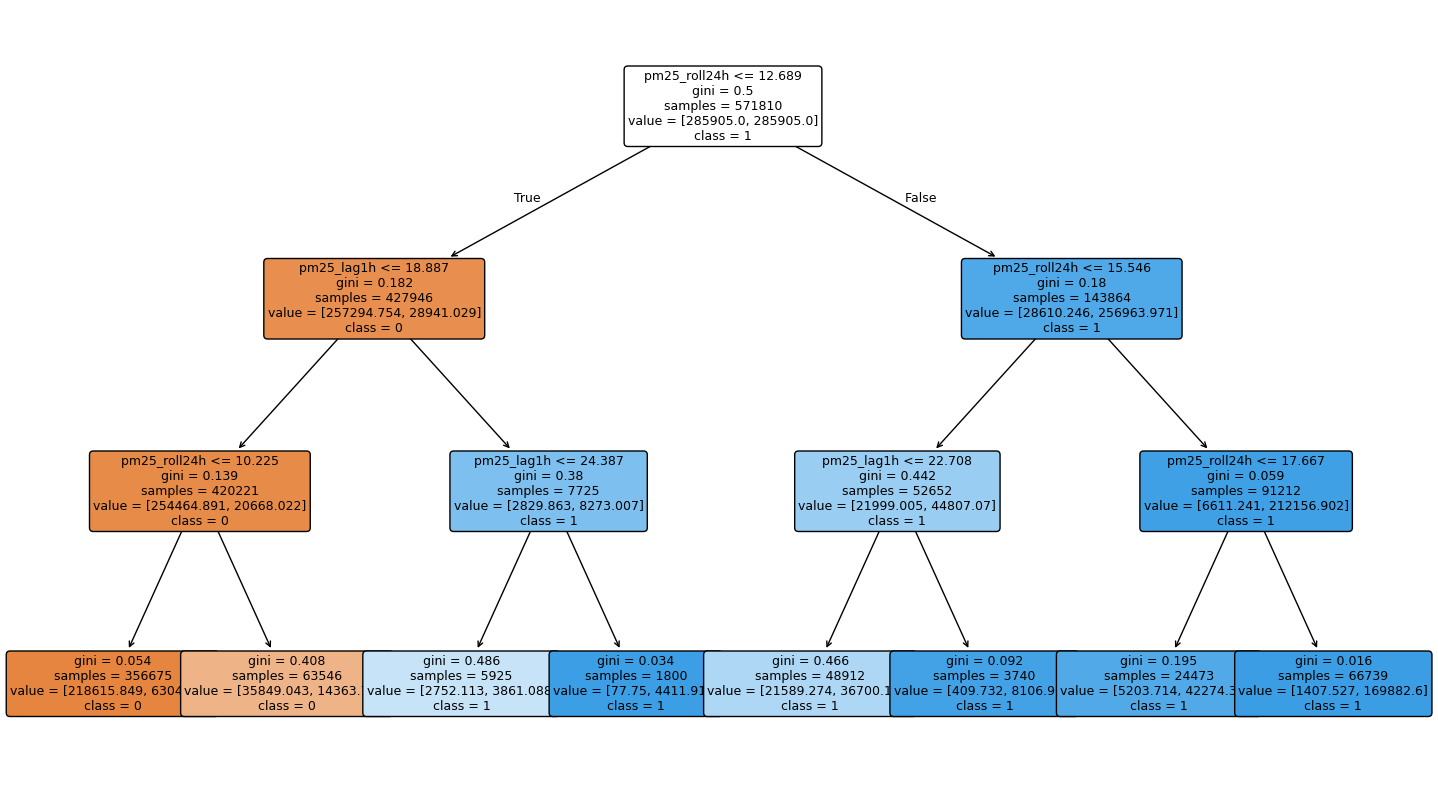

In [9]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model_cart,
    feature_names=X_train.columns,
    class_names=["0", "1"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.show()

On évalue ensuite nos modèles

In [10]:
cart_eval = evaluate_model(model_cart, X_test, y_test)
rf_eval = evaluate_model(model_rf, X_test, y_test)
# Pour le modèle logistique, il faut standardidser d'abord
model_log, scaler, X_train_scaled, X_test_scaled = train_logistic_regression(X_train, y_train, X_test)
log_eval = evaluate_model(model_log, X_test_scaled, y_test)

Puis on les compare à léchelle globale

In [11]:
from src.models import compare_models

compare_models(cart_eval, rf_eval, log_eval)

,modele,f1_score,precision,recall
1,Random Forest,0.758877,0.658391,0.895561
2,Régression logistique,0.751565,0.652221,0.886611
0,CART,0.749950,0.634969,0.915782


Les performances des modèles sont d’abord évaluées globalement afin de comparer leur capacité prédictive. Le modèle le plus performant est ensuite analysé à l’échelle de chaque station. Cette approche permet de mettre en évidence des disparités spatiales importantes, certaines stations étant significativement mieux prédites que d’autres.
Dans notre cas, le modèle le plus performant est la forêt aléatoire

In [12]:
y_pred = model_rf.predict(X_test)
df_test = X_test.copy()

df_test["y_true"] = y_test
df_test["y_pred"] = y_pred

df_test["nom_station"] = df.loc[X_test.index, "nom_station"]

In [13]:
from src.models import metrics_par_station

df_station_results = metrics_par_station(df_test)
df_station_results.head()

,nom_station,f1_score,precision,recall,nb_obs
8,PARIS 18eme,0.820090,0.778648,0.866192,7930
10,RAMBOUILLET,0.815483,0.753472,0.888616,8014
11,RD934 Coulommiers,0.804683,0.746667,0.872475,7979
12,RN20 - MONTLHERY,0.803566,0.722041,0.905843,8015
9,PARIS 1er Les Halles,0.791255,0.684993,0.936537,7840


Visualisation

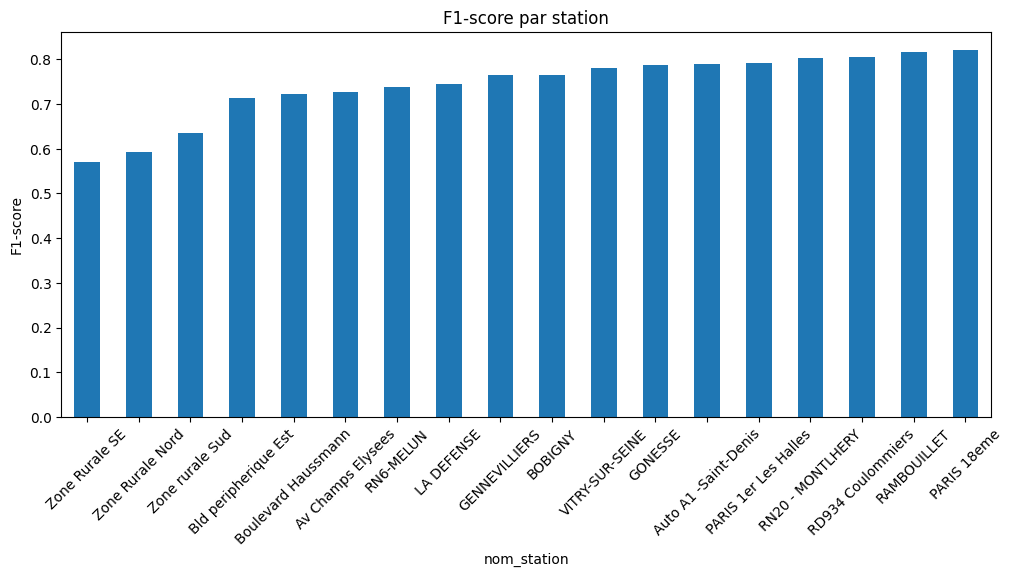

In [14]:
import matplotlib.pyplot as plt

df_station_results.sort_values("f1_score").plot(
    x="nom_station",
    y="f1_score",
    kind="bar",
    figsize=(12,5),
    legend=False
)

plt.title("F1-score par station")
plt.ylabel("F1-score")
plt.xticks(rotation=45)
plt.show()